# POC: RLM vs RAG vs LLM — Long-Form Document Summarization
## Microsoft Q2 FY2026 Earnings Call Transcript  ·  3-Way Comparison

> **Hypothesis:** DSPy RLM achieves higher section recall and lower hallucination count than
> vanilla RAG on a long earnings call transcript, at the cost of higher latency and token spend.
> A full-context LLM baseline tests whether retrieval is even necessary when the document fits
> in the context window.

| Component | Choice |
|---|---|
| LLM (generation) | OpenAI `gpt-4o-mini` |
| Embedding | IBM Granite `granite-embedding-125m-english` — local HuggingFace |
| Vector DB | FAISS (in-memory) |
| RLM Framework | DSPy `dspy.RLM` (GPT-4o-mini root + GPT-4o-mini sub) |
| Transcript | MSFT Q2 FY2026 Earnings Call (~363 lines, real transcript) |

---

## Section 0 — Environment & Shared Clients
> Load API key, create shared OpenAI client, Granite embedder, tiktoken encoder, and DSPy LMs.

In [1]:
import os, sys, time, re, json, pathlib
import numpy as np

# ── Load API key from v2's .env ──────────────────────────────
env_path = pathlib.Path("../../v2/.env")
if env_path.exists():
    with open(env_path) as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                key, val = line.split("=", 1)
                os.environ[key.strip()] = val.strip().strip('"').strip("'")

assert os.environ.get("OPENAI_API_KEY"), "OPENAI_API_KEY not found — add it to Experiment/v2/.env"

# ── Ensure Deno is on PATH (required for DSPy RLM sandbox) ──
deno_dir = pathlib.Path.home() / ".deno" / "bin"
if deno_dir.exists() and str(deno_dir) not in os.environ.get("PATH", ""):
    os.environ["PATH"] = str(deno_dir) + os.pathsep + os.environ.get("PATH", "")
    print(f"Added {deno_dir} to PATH")

import subprocess
deno_check = subprocess.run(["deno", "--version"], capture_output=True, text=True)
assert deno_check.returncode == 0, "Deno not found — install via: curl -fsSL https://deno.land/install.sh | sh"
print(f"Deno available: {deno_check.stdout.splitlines()[0]}")

# ── Shared OpenAI client ─────────────────────────────────────
from openai import OpenAI
oai = OpenAI()
print("OpenAI client ready")

# ── Shared tiktoken encoder ──────────────────────────────────
import tiktoken
enc = tiktoken.get_encoding("cl100k_base")
print("tiktoken encoder ready")

# ── Shared Granite embedding model ───────────────────────────
from sentence_transformers import SentenceTransformer

GRANITE_ID = "ibm-granite/granite-embedding-125m-english"
print(f"Loading {GRANITE_ID} ...")
granite = SentenceTransformer(GRANITE_ID)
test = granite.encode(["test"])
print(f"Granite loaded  |  dim={test.shape[1]}  |  device={granite.device}")

# ── Shared DSPy LMs (both GPT-4o-mini) ───────────────────────
import dspy
root_lm = dspy.LM(model="openai/gpt-4o-mini", temperature=0.1, cache=False)
sub_lm  = dspy.LM(model="openai/gpt-4o-mini", temperature=0.1, cache=False)
dspy.configure(lm=root_lm)
print("DSPy configured")
print("  Root LM : openai/gpt-4o-mini  (orchestration + generation)")
print("  Sub  LM : openai/gpt-4o-mini  (REPL sub-calls)")

Added C:\Users\prave\.deno\bin to PATH


Deno available: deno 2.7.4 (stable, release, x86_64-pc-windows-msvc)


OpenAI client ready


tiktoken encoder ready


Loading ibm-granite/granite-embedding-125m-english ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Granite loaded  |  dim=768  |  device=cpu


DSPy configured
  Root LM : openai/gpt-4o-mini  (orchestration + generation)
  Sub  LM : openai/gpt-4o-mini  (REPL sub-calls)


## Section 1 — Document Ingestion
Read the real MSFT Q2 FY2026 transcript from local file.

In [2]:
transcript_path = pathlib.Path("../data/msft_ec.txt")
assert transcript_path.exists(), f"Transcript not found at {transcript_path}"

raw_text = transcript_path.read_text(encoding="utf-8")
TOTAL_DOC_TOKENS = len(enc.encode(raw_text))

print(f"Transcript : {transcript_path}")
print(f"Characters : {len(raw_text):,}")
print(f"Lines      : {raw_text.count(chr(10)):,}")
print(f"Tokens     : {TOTAL_DOC_TOKENS:,}  (cl100k_base)")
print(f"\nFirst 300 chars:\n{raw_text[:300]}")

Transcript : ..\data\msft_ec.txt
Characters : 51,711
Lines      : 362
Tokens     : 10,954  (cl100k_base)

First 300 chars:
Microsoft FY26 Second Quarter Earnings Conference Call
Jonathan Neilson, Satya Nadella, Amy Hood
Wednesday January 28, 2026
JONATHAN NEILSON: 
Good afternoon and thank you for joining us today. On the call with me are Satya Nadella, chairman and chief executive officer, Amy Hood, chief financial off


## Section 2 — Ground Truth
Load comprehensive ground truth from JSON (31 revenue + 18 guidance + 9 risk + 8 analyst + 35 entities).

In [3]:
gt_path = pathlib.Path("../data/ground_truth.json")
assert gt_path.exists(), f"Ground truth not found at {gt_path}"

with open(gt_path) as f:
    GROUND_TRUTH = json.load(f)

total_items = sum(len(v) for v in GROUND_TRUTH.values())
print(f"✓ Ground truth loaded from {gt_path}")
for k, v in GROUND_TRUTH.items():
    print(f"  {k:<25}: {len(v)} items")
print(f"  {'TOTAL':<25}: {total_items} items")

✓ Ground truth loaded from ..\data\ground_truth.json
  revenue_figures          : 29 items
  guidance_statements      : 19 items
  risk_factors             : 9 items
  analyst_topics           : 8 items
  key_entities             : 37 items
  TOTAL                    : 102 items


## Section 3 — Metrics Infrastructure
`MetricsTracker` dataclass, `PRICES` dict, and `score_output()` function.

In [4]:
from dataclasses import dataclass, field
from typing import Dict, List

PRICES = {
    "gpt-4o-mini": {"input": 0.15, "output": 0.60},
}

@dataclass
class MetricsTracker:
    system_name: str
    start_time: float = field(default_factory=time.perf_counter)

    total_input_tokens:  int = 0
    total_output_tokens: int = 0
    embedding_tokens:    int = 0
    api_call_count:      int = 0
    model_calls:         Dict[str, int] = field(default_factory=dict)
    end_time:            float = 0.0
    first_output_time:   float = 0.0

    sections_populated:    List[str] = field(default_factory=list)
    revenue_figures_found: List[str] = field(default_factory=list)
    guidance_found:        List[str] = field(default_factory=list)
    entities_found:        List[str] = field(default_factory=list)
    hallucination_count:   int = 0
    repl_iterations:       int = 0
    sub_llm_calls:         int = 0
    code_strategies:       List[str] = field(default_factory=list)

    def log_api_call(self, model, input_tokens, output_tokens):
        self.total_input_tokens  += input_tokens
        self.total_output_tokens += output_tokens
        self.api_call_count      += 1
        self.model_calls[model]   = self.model_calls.get(model, 0) + 1

    def log_embedding(self, n):
        self.embedding_tokens += n

    def mark_first_output(self):
        if self.first_output_time == 0.0:
            self.first_output_time = time.perf_counter()

    def finish(self):
        self.end_time = time.perf_counter()

    @property
    def wall_clock_seconds(self):
        return (self.end_time or time.perf_counter()) - self.start_time

    @property
    def ttff_seconds(self):
        if self.first_output_time == 0.0:
            return self.wall_clock_seconds
        return self.first_output_time - self.start_time

    @property
    def estimated_cost_usd(self):
        price = PRICES["gpt-4o-mini"]
        return (self.total_input_tokens / 1e6 * price["input"] +
                self.total_output_tokens / 1e6 * price["output"])

    @property
    def section_recall(self):
        return len(self.sections_populated)

    def summary_dict(self):
        return {
            "system":               self.system_name,
            "total_input_tokens":   self.total_input_tokens,
            "total_output_tokens":  self.total_output_tokens,
            "embedding_tokens":     self.embedding_tokens,
            "api_call_count":       self.api_call_count,
            "model_calls":          self.model_calls,
            "estimated_cost_usd":   round(self.estimated_cost_usd, 5),
            "wall_clock_s":         round(self.wall_clock_seconds, 2),
            "ttff_s":               round(self.ttff_seconds, 2),
            "section_recall_of_5":  self.section_recall,
            "sections_populated":   self.sections_populated,
            "revenue_recall_pct":   round(len(self.revenue_figures_found) /
                                          max(len(GROUND_TRUTH["revenue_figures"]), 1) * 100, 1),
            "guidance_recall_pct":  round(len(self.guidance_found) /
                                          max(len(GROUND_TRUTH["guidance_statements"]), 1) * 100, 1),
            "entity_recall_pct":    round(len(self.entities_found) /
                                          max(len(GROUND_TRUTH["key_entities"]), 1) * 100, 1),
            "hallucination_count":  self.hallucination_count,
            "repl_iterations":      self.repl_iterations,
            "sub_llm_calls":        self.sub_llm_calls,
            "code_strategies":      self.code_strategies,
        }

print("MetricsTracker ready  (GPT-4o-mini pricing: $0.15 in / $0.60 out per 1M)")

MetricsTracker ready  (GPT-4o-mini pricing: $0.15 in / $0.60 out per 1M)


In [5]:
def score_output(tracker, output, source_text):
    """Score pipeline output against loaded GROUND_TRUTH."""
    REQUIRED = ["executive_summary", "revenue_by_segment",
                "forward_guidance", "risk_factors", "analyst_qa_themes"]

    for sec in REQUIRED:
        if len(str(output.get(sec, "")).strip()) > 20:
            tracker.sections_populated.append(sec)

    out_text = json.dumps(output).lower()

    for key, value in GROUND_TRUTH["revenue_figures"].items():
        m = re.search(r"[\d.]+", value)
        if m and m.group() in out_text:
            tracker.revenue_figures_found.append(key)

    for stmt in GROUND_TRUTH["guidance_statements"]:
        nums = re.findall(r"[\d.]+", stmt)
        if any(n in out_text for n in nums if len(n) >= 2):
            tracker.guidance_found.append(stmt)

    for e in GROUND_TRUTH["key_entities"]:
        if e.lower() in out_text:
            tracker.entities_found.append(e)

    source_nums = set(re.findall(r"[\d.]+", source_text))
    claimed = re.findall(
        r"\$[\d.,]+[BMKbmk%]|[\d.,]+%|[\d.]+\s*(?:billion|percent|million)",
        json.dumps(output), re.I)
    tracker.hallucination_count = sum(
        1 for c in claimed
        for n in re.findall(r"[\d.]+", c)
        if len(n) >= 3 and n not in source_nums)
    return tracker

print("✓ score_output() defined")

✓ score_output() defined


## Section 4 — FAISS Index (shared for RAG)
**Granite embedding → FAISS IndexFlatIP**

In [6]:
import faiss

def chunk_text(text, chunk_size=512, overlap=50):
    tokens, chunks, step = enc.encode(text), [], chunk_size - overlap
    for start in range(0, len(tokens), step):
        chunks.append(enc.decode(tokens[start : start + chunk_size]))
        if start + chunk_size >= len(tokens):
            break
    return chunks

def build_faiss_index(chunks, embedder):
    print(f"  Embedding {len(chunks)} chunks...", end=" ", flush=True)
    embs = np.array(embedder.encode(chunks, show_progress_bar=False), dtype=np.float32)
    faiss.normalize_L2(embs)
    idx = faiss.IndexFlatIP(embs.shape[1])
    idx.add(embs)
    print(f"done  ({idx.ntotal} vectors x {embs.shape[1]} dims)")
    return idx

def retrieve(query, index, chunks, embedder, k=5):
    qv = np.array(embedder.encode([query], show_progress_bar=False), dtype=np.float32)
    faiss.normalize_L2(qv)
    _, idxs = index.search(qv, k)
    return [chunks[i] for i in idxs[0] if i < len(chunks)]

print("Building FAISS index from transcript...")
chunks      = chunk_text(raw_text)
faiss_index = build_faiss_index(chunks, granite)
EMB_TOKENS  = sum(len(enc.encode(c)) for c in chunks)
print(f"  Chunks           : {len(chunks)}")
print(f"  Embedding tokens : {EMB_TOKENS:,}  (local Granite, $0 cost)")

Building FAISS index from transcript...
  Embedding 24 chunks... 

done  (24 vectors x 768 dims)
  Chunks           : 24
  Embedding tokens : 12,104  (local Granite, $0 cost)


## Section 5 — RAG Pipeline
**Granite embedding → FAISS → GPT-4o-mini (single combined call)**

Retrieves relevant chunks for all 5 section queries, deduplicates, applies regex pattern
analysis, then makes a **single LLM call** to generate one JSON object with all 5 sections.

In [7]:
RAG_QUERIES = {
    "executive_summary": (
        "Overall financial performance Q2 FY2026: total revenue, cloud revenue, "
        "operating income, net income, EPS, headline growth rates."
    ),
    "revenue_by_segment": (
        "All segment revenue figures and YoY growth: Azure, Intelligent Cloud, "
        "Productivity, Office 365, Dynamics, Dynamics 365, LinkedIn, More Personal "
        "Computing, Windows, Xbox, Surface, Search advertising."
    ),
    "forward_guidance": (
        "Q3 FY2026 guidance: revenue ranges for every segment, COGS, operating "
        "expenses, other income, effective tax rate, Azure constant-currency growth, FX impact."
    ),
    "risk_factors": (
        "Risks, headwinds, and challenges mentioned by management: macro, FX, "
        "AI capacity constraints, competition, regulatory scrutiny, CapEx concerns."
    ),
    "analyst_qa_themes": (
        "Analyst Q&A summary: each analyst name, firm, question topic, "
        "and key points from management response."
    ),
}

# ── Regex patterns used during chunk content identification ──
RAG_REGEX_PATTERNS = {
    "Revenue Figures": [
        r"\$[\d.,]+\s*(?:billion|B\b)",
        r"[\d.]+%?\s*(?:growth|increase|grew|up\b)",
        r"revenue\s+(?:was|of|grew|increased)",
    ],
    "Segment Names": [
        r"(?:Azure|Intelligent Cloud)",
        r"(?:Productivity\s+and\s+Business\s+Processes)",
        r"(?:More\s+Personal\s+Computing)",
        r"(?:Dynamics\s+365|LinkedIn|Xbox|Surface)",
    ],
    "Guidance Ranges": [
        r"(?:expect|guidance|outlook|anticipate)",
        r"\$[\d.,]+\s*(?:billion|B\b)\s*to\s*\$[\d.,]+",
        r"(?:Q3|third\s+quarter).*?(?:revenue|growth)",
    ],
    "Risk Indicators": [
        r"(?:risk|challenge|headwind|concern|constraint)",
        r"(?:impairment|decline|volatility|pressure)",
        r"(?:competition|regulatory)",
    ],
    "Q&A Markers": [
        r"(?:question|analyst|Q&A|follow[\s-]?up)",
        r"(?:Morgan\s+Stanley|UBS|Bernstein|Jefferies|Deutsche\s+Bank|J\.?P\.?\s*Morgan|Barclays)",
    ],
}

RAG_SYSTEM = (
    "You are a precise financial analyst assistant. Using ONLY the transcript "
    "context provided, produce a JSON object with exactly these 5 keys:\n"
    "  - executive_summary\n"
    "  - revenue_by_segment\n"
    "  - forward_guidance\n"
    "  - risk_factors\n"
    "  - analyst_qa_themes\n\n"
    "Each value should be a detailed string with ALL numbers and percentages "
    "found in the context. If something is absent, write "
    "'Not found in retrieved chunks'. Do not invent figures.\n"
    "Return ONLY valid JSON."
)

K = 5
rag_tracker = MetricsTracker("RAG  (Granite-FAISS + GPT-4o-mini)")
rag_tracker.log_embedding(EMB_TOKENS)

print(f"Running RAG  k={K}  — retrieving chunks for all 5 queries...\n" + "-" * 60)

# ── Step 1: Retrieve chunks for each query ───────────────────
all_retrieved = {}
for section, query in RAG_QUERIES.items():
    retrieved = retrieve(query, faiss_index, chunks, granite, k=K)
    all_retrieved[section] = retrieved
    rag_tracker.log_embedding(len(enc.encode(query)))
    print(f"  [{section:<22}]  retrieved {len(retrieved)} chunks")

# ── Step 2: Deduplicate chunks preserving order ──────────────
seen = set()
combined_chunks = []
for section_chunks in all_retrieved.values():
    for chunk in section_chunks:
        chunk_id = hash(chunk)
        if chunk_id not in seen:
            seen.add(chunk_id)
            combined_chunks.append(chunk)

combined_context = "\n\n---\n\n".join(combined_chunks)
context_tokens = len(enc.encode(combined_context))
print(f"\n  Total unique chunks : {len(combined_chunks)} / {K * len(RAG_QUERIES)} retrieved")
print(f"  Context tokens      : {context_tokens:,}")

# ── Step 3: Regex pattern analysis on retrieved chunks ───────
import pandas as pd
from IPython.display import display

pattern_rows = []
for category, patterns in RAG_REGEX_PATTERNS.items():
    for pat in patterns:
        matches_per_chunk = [
            i for i, chunk in enumerate(combined_chunks)
            if re.search(pat, chunk, re.I)
        ]
        sample_matches = []
        for idx in matches_per_chunk[:2]:
            m = re.search(pat, combined_chunks[idx], re.I)
            if m:
                sample_matches.append(m.group()[:40])
        pattern_rows.append({
            "Category": category,
            "Regex Pattern": pat,
            "Chunks Matched": len(matches_per_chunk),
            "Sample Matches": " | ".join(sample_matches) if sample_matches else "—",
        })

df_patterns = pd.DataFrame(pattern_rows)
print(f"\n{'='*60}\n  RAG Chunk Retrieval — Regex Pattern Analysis\n{'='*60}")
display(df_patterns.style
    .hide(axis="index")
    .set_table_styles([
        {"selector": "th", "props": [("background", "#1e3a5f"), ("color", "#f1f5f9"),
                                      ("padding", "6px 10px"), ("font-size", "11px")]},
        {"selector": "td", "props": [("padding", "4px 10px"), ("font-size", "11px"),
                                      ("border", "1px solid #e2e8f0")]},
    ]))

# ── Step 4: Single LLM call with combined context ────────────
print(f"\n  Making single GPT-4o-mini call with {context_tokens:,} context tokens...")
t0 = time.perf_counter()

resp = oai.chat.completions.create(
    model="gpt-4o-mini",
    max_tokens=4000,
    temperature=0.1,
    response_format={"type": "json_object"},
    messages=[
        {"role": "system", "content": RAG_SYSTEM},
        {"role": "user", "content": (
            f"TRANSCRIPT CONTEXT (from {len(combined_chunks)} retrieved chunks):\n"
            f"{combined_context}\n\n"
            "Generate a JSON object with all 5 sections based on the above context."
        )},
    ],
)

raw_answer = resp.choices[0].message.content
rag_tracker.log_api_call("gpt-4o-mini",
                          resp.usage.prompt_tokens,
                          resp.usage.completion_tokens)
rag_tracker.mark_first_output()

try:
    rag_output = json.loads(raw_answer)
except json.JSONDecodeError:
    print("  WARNING: Failed to parse JSON response, wrapping raw text")
    rag_output = {"executive_summary": raw_answer, "revenue_by_segment": "",
                  "forward_guidance": "", "risk_factors": "", "analyst_qa_themes": ""}

rag_tracker.finish()
rag_tracker = score_output(rag_tracker, rag_output, raw_text)

rs = rag_tracker.summary_dict()
print(f"\n{'─'*60}")
print(f"RAG done  {rs['wall_clock_s']:.1f}s  |  "
      f"{rs['total_input_tokens']:,} in  {rs['total_output_tokens']:,} out  |  "
      f"${rs['estimated_cost_usd']:.5f}  |  "
      f"sections {rs['section_recall_of_5']}/5  |  "
      f"revenue {rs['revenue_recall_pct']}%  |  "
      f"API calls: {rs['api_call_count']}")

Running RAG  k=5  — retrieving chunks for all 5 queries...
------------------------------------------------------------


  [executive_summary     ]  retrieved 5 chunks


  [revenue_by_segment    ]  retrieved 5 chunks


  [forward_guidance      ]  retrieved 5 chunks


  [risk_factors          ]  retrieved 5 chunks


  [analyst_qa_themes     ]  retrieved 5 chunks

  Total unique chunks : 14 / 25 retrieved
  Context tokens      : 7,192

  RAG Chunk Retrieval — Regex Pattern Analysis


Category,Regex Pattern,Chunks Matched,Sample Matches
Revenue Figures,"\$[\d.,]+\s*(?:billion|B\b)",9,$32.9 billion | $34.55 billion
Revenue Figures,[\d.]+%?\s*(?:growth|increase|grew|up\b),3,30% growth | . Growth
Revenue Figures,revenue\s+(?:was|of|grew|increased),5,Revenue was | revenue of
Segment Names,(?:Azure|Intelligent Cloud),10,Intelligent Cloud | Intelligent Cloud
Segment Names,(?:Productivity\s+and\s+Business\s+Processes),4,Productivity and Business Processes | Productivity and Business Processes
Segment Names,(?:More\s+Personal\s+Computing),3,More Personal Computing | More Personal Computing
Segment Names,(?:Dynamics\s+365|LinkedIn|Xbox|Surface),6,Xbox | LinkedIn
Guidance Ranges,(?:expect|guidance|outlook|anticipate),11,expect | expect
Guidance Ranges,"\$[\d.,]+\s*(?:billion|B\b)\s*to\s*\$[\d.,]+",0,—
Guidance Ranges,(?:Q3|third\s+quarter).*?(?:revenue|growth),1,Q3 revenue



  Making single GPT-4o-mini call with 7,192 context tokens...



────────────────────────────────────────────────────────────
RAG done  14.5s  |  7,302 in  647 out  |  $0.00148  |  sections 5/5  |  revenue 79.3%  |  API calls: 1


In [8]:
print("\n" + "=" * 60 + "\n  RAG OUTPUT (JSON)\n" + "=" * 60)
rag_json_str = json.dumps(rag_output, indent=2)
print(rag_json_str[:3000])
if len(rag_json_str) > 3000:
    print(f"\n  ... [{len(rag_json_str)-3000} more chars]")


  RAG OUTPUT (JSON)
{
  "executive_summary": "This quarter, revenue was $81.3 billion, up 17% and 15% in constant currency. Gross margin dollars increased 16% and 14% in constant currency while operating income increased 21% and 19% in constant currency. Earnings per share was $4.14, an increase of 24% and 21% in constant currency. Company gross margin percentage was 68%, down slightly year-over-year. Operating expenses increased 5% and 4% in constant currency. Operating margins increased year-over-year to 47%. Microsoft Cloud revenue was $51.5 billion and grew 26% and 24% in constant currency. Commercial bookings increased 230% and 228% in constant currency. Commercial remaining performance obligation increased to $625 billion and was up 110% year-over-year.",
  "revenue_by_segment": "Intelligent Cloud segment revenue was $32.9 billion, growing 29% and 28% in constant currency. Azure and other cloud services revenue grew 39% and 38% in constant currency. More Personal Computing reven

## Section 6 — LLM Pipeline (Full Context)
**Full transcript → GPT-4o-mini** — single call returning one JSON object with all 5 sections.

In [9]:
LLM_SYSTEM = (
    "You are a precise financial analyst assistant. Using ONLY the full earnings call "
    "transcript provided, produce a JSON object with exactly these 5 keys:\n"
    "  - executive_summary\n"
    "  - revenue_by_segment\n"
    "  - forward_guidance\n"
    "  - risk_factors\n"
    "  - analyst_qa_themes\n\n"
    "Each value should be a detailed string with ALL numbers and percentages "
    "found in the transcript. If something is absent, write 'Not found in transcript'. "
    "Do not invent figures.\n"
    "Return ONLY valid JSON."
)

llm_tracker = MetricsTracker("LLM  (GPT-4o-mini Full Context)")

print(f"Running LLM (full context, single call)...\n" + "-" * 60)

t0 = time.perf_counter()
resp = oai.chat.completions.create(
    model="gpt-4o-mini",
    max_tokens=4000,
    temperature=0.1,
    response_format={"type": "json_object"},
    messages=[
        {"role": "system", "content": LLM_SYSTEM},
        {"role": "user", "content": (
            f"FULL TRANSCRIPT :\n{raw_text}\n\n"
            "Generate a JSON object with all 5 sections based on the full transcript."
        )},
    ],
)

raw_answer = resp.choices[0].message.content
llm_tracker.log_api_call("gpt-4o-mini",
                          resp.usage.prompt_tokens,
                          resp.usage.completion_tokens)
llm_tracker.mark_first_output()

try:
    llm_output = json.loads(raw_answer)
except json.JSONDecodeError:
    print("  WARNING: Failed to parse JSON response, wrapping raw text")
    llm_output = {"executive_summary": raw_answer, "revenue_by_segment": "",
                  "forward_guidance": "", "risk_factors": "", "analyst_qa_themes": ""}

llm_tracker.finish()
llm_tracker = score_output(llm_tracker, llm_output, raw_text)

ms = llm_tracker.summary_dict()
print(f"{'─'*60}")
print(f"LLM done  {ms['wall_clock_s']:.1f}s  |  "
      f"{ms['total_input_tokens']:,} in  {ms['total_output_tokens']:,} out  |  "
      f"${ms['estimated_cost_usd']:.5f}  |  "
      f"sections {ms['section_recall_of_5']}/5  |  "
      f"revenue {ms['revenue_recall_pct']}%  |  "
      f"API calls: {ms['api_call_count']}")

Running LLM (full context, single call)...
------------------------------------------------------------


────────────────────────────────────────────────────────────
LLM done  12.3s  |  11,060 in  666 out  |  $0.00206  |  sections 5/5  |  revenue 82.8%  |  API calls: 1


In [10]:
print("\n" + "=" * 60 + "\n  LLM OUTPUT (JSON)\n" + "=" * 60)
llm_json_str = json.dumps(llm_output, indent=2)
print(llm_json_str[:3000])
if len(llm_json_str) > 3000:
    print(f"\n  ... [{len(llm_json_str)-3000} more chars]")


  LLM OUTPUT (JSON)
{
  "executive_summary": "This quarter, revenue was $81.3 billion, up 17% and 15% in constant currency. Gross margin dollars increased 16% and 14% in constant currency while operating income increased 21% and 19% in constant currency. Earnings per share was $4.14, an increase of 24% and 21% in constant currency. Microsoft Cloud surpassed $50 billion in revenue for the first time, up 26% year-over-year. Capital expenditures were $37.5 billion, and cash flow from operations was $35.8 billion, up 60%. Free cash flow was $5.9 billion. We returned $12.7 billion to shareholders through dividends and share repurchases, an increase of 32% year-over-year.",
  "revenue_by_segment": "Revenue from Productivity and Business Processes was $34.1 billion and grew 16% and 14% in constant currency. M365 commercial cloud revenue increased 17% and 14% in constant currency. M365 consumer cloud revenue increased 29% and 27% in constant currency. LinkedIn revenue increased 11% and 10% in

## Section 7 — RLM Pipeline (DSPy + GPT-4o-mini)
The LLM writes Python code to explore the transcript in a sandbox. Both root and sub calls
use GPT-4o-mini. Makes a single RLM query returning all 5 sections.

In [11]:
class EarningsSignature(dspy.Signature):
    """
    Analyze a Microsoft earnings call transcript using Python code in a REPL.
    Systematically search every section. Extract ALL financial figures,
    guidance numbers, risk statements, and Q&A themes. Do not skip any section.
    """
    transcript: str = dspy.InputField(
        desc="Full earnings call transcript text")
    task: str = dspy.InputField(
        desc="Extraction instructions")
    executive_summary: str = dspy.OutputField(
        desc="5-sentence overview: total revenue, cloud, operating income, EPS, growth rates")
    revenue_by_segment: str = dspy.OutputField(
        desc="ALL segments with exact $ and YoY %: Azure, Intelligent Cloud, Productivity, "
             "Office 365, Dynamics 365, LinkedIn, MPC, Xbox, Surface, Search")
    forward_guidance: str = dspy.OutputField(
        desc="ALL Q3 FY2026 guidance ranges per segment + COGS + OpEx + tax rate + FX impact")
    risk_factors: str = dspy.OutputField(
        desc="ALL risks and headwinds: capacity constraints, CapEx ROI, OpenAI concentration, "
             "gaming impairment, memory pricing, FX, competition")
    analyst_qa_themes: str = dspy.OutputField(
        desc="Each analyst exchange: name, firm, question, key answer points")

print("✓ EarningsSignature defined")

✓ EarningsSignature defined


In [12]:
RLM_TASK = """
Extract a complete structured summary from this Microsoft Q2 FY2026 earnings transcript.
Return results as structured output covering all 5 sections in a single pass.
Use Python code to:
  1. Search for segment names to locate relevant paragraphs
  2. Extract every dollar figure and percentage near each segment
  3. Find all guidance statements ('We expect...')
  4. Extract every risk/headwind mentioned
  5. Find the Q&A section and summarise each analyst exchange
  6. Search for CapEx figures, RPO, free cash flow, and other financial metrics

Use loops to scan the entire document. Include every number mentioned.
"""

rlm_tracker = MetricsTracker("RLM  (DSPy dspy.RLM + GPT-4o-mini)")
t0 = time.perf_counter()

rlm_module = dspy.RLM(
    signature=EarningsSignature,
    max_iterations=15,
    max_llm_calls=40,
    sub_lm=sub_lm,
    verbose=True,
)

print(f"Running DSPy RLM (GPT-4o-mini) on whole transcript...\n" + "=" * 60)
rlm_result = rlm_module(transcript=raw_text, task=RLM_TASK)
t1 = time.perf_counter()

rlm_tracker.start_time        = t0
rlm_tracker.end_time          = t1
rlm_tracker.first_output_time = t1
print("=" * 60)
print(f"\nRLM done in {t1 - t0:.1f}s")

Running DSPy RLM (GPT-4o-mini) on whole transcript...


2026/03/10 00:26:33 INFO dspy.predict.rlm: RLM iteration 1/15
Reasoning: I have access to the earnings call transcript and the task instructions for extracting structured information. The first step is to explore the transcript to understand its structure and identify key sections such as segment names, guidance statements, risk factors, and the Q&A section. I will print a portion of the transcript to get a better sense of how the information is organized and what patterns I can look for in the text.
Code:
```python
# Print the first 1000 characters of the transcript to explore its structure
print(transcript[:1000])
```


2026/03/10 00:26:41 INFO dspy.predict.rlm: RLM iteration 2/15
Reasoning: I have printed the first 1000 characters of the transcript, which provides an introduction to the earnings call and mentions key participants. However, it does not contain specific financial figures, guidance statements, or risk factors. To proceed, I need to identify the main sections of the transcript, such as revenue segments, guidance, risks, and the Q&A section. I will search for keywords that typically indicate these sections, such as "revenue," "guidance," "risk," and "Q&A." I will extract a larger portion of the transcript to locate these sections more effectively.
Code:
```python
# Print the next 2000 characters of the transcript to explore more content and locate key sections
print(transcript[1000:3000])
```


2026/03/10 00:26:46 INFO dspy.predict.rlm: RLM iteration 3/15
Reasoning: I have explored the initial sections of the transcript and identified that it contains introductory remarks, mentions of financial measures, and forward-looking statements. I also found a significant statement regarding the Microsoft Cloud surpassing $50 billion in revenue, which indicates that financial figures are present. To extract structured information, I need to identify specific sections such as revenue by segment, guidance statements, risk factors, and the Q&A section. I will now search for keywords that indicate these sections and extract relevant paragraphs. I will use regular expressions to find financial figures and guidance statements.
Code:
```python
import re

# Define a function to extract relevant sections from the transcript
def extract_sections(transcript):
    # Search for revenue figures
    revenue_pattern = r'(\$[\d,]+(?:\.\d{1,2})?)\s*(?:in revenue|revenue|up|growth|increase|decrease|year-

2026/03/10 00:26:52 INFO dspy.predict.rlm: RLM iteration 4/15
Reasoning: I have successfully extracted guidance statements from the transcript, but I did not find any revenue figures. The risk factors were also identified, but they were not specific enough. The next step is to refine the extraction process for revenue figures and ensure that I capture all relevant financial data. I will adjust the revenue extraction pattern to be more inclusive and also look for specific phrases that indicate revenue figures. Additionally, I will enhance the risk extraction to capture more detailed statements. I will execute the updated extraction code to gather more comprehensive results.
Code:
```python
import re

# Define a function to extract relevant sections from the transcript
def extract_sections(transcript):
    # Search for revenue figures with a more inclusive pattern
    revenue_pattern = r'(\$[\d,]+(?:\.\d{1,2})?)\s*(?:in revenue|revenue|up|growth|increase|decrease|year-over-year|YoY|for t

...

2026/03/10 00:27:42 INFO dspy.predict.rlm: RLM iteration 12/15
Reasoning: I have been attempting to extract revenue figures from the transcript but have not been successful so far. The guidance statements have been extracted successfully, and I have identified some risk factors, but they lack specific context. To improve the extraction of revenue figures, I will refine the revenue extraction pattern further by including more phrases that typically accompany financial figures. Additionally, I will enhance the risk extraction to capture more detailed statements. I will execute the updated extraction code to gather more comprehensive results.
Code:
```python
import re

# Define a function to extract relevant sections from the transcript
def extract_sections(transcript):
    # Search for revenue figures with a more inclusive pattern
    revenue_pattern = r'(\$[\d,]+(?:\.\d{1,2})?)\s*(?:in revenue|revenue|up|growth|increase|decrease|year-over-year|YoY|for the quarter|for the year|total reve

2026/03/10 00:27:48 INFO dspy.predict.rlm: RLM iteration 13/15
Reasoning: I have been attempting to extract revenue figures from the transcript but have not been successful so far. The guidance statements have been extracted successfully, and I have identified some risk factors, but they lack specific context. To improve the extraction of revenue figures, I will refine the revenue extraction pattern further by including more phrases that typically accompany financial figures. Additionally, I will enhance the risk extraction to capture more detailed statements. I will execute the updated extraction code to gather more comprehensive results.
Code:
```python
import re

# Define a function to extract relevant sections from the transcript
def extract_sections(transcript):
    # Search for revenue figures with a more inclusive pattern
    revenue_pattern = r'(\$[\d,]+(?:\.\d{1,2})?)\s*(?:in revenue|revenue|up|growth|increase|decrease|year-over-year|YoY|for the quarter|for the year|total reve

2026/03/10 00:27:54 INFO dspy.predict.rlm: RLM iteration 14/15
Reasoning: I have been attempting to extract revenue figures from the transcript but have not been successful so far. The guidance statements have been extracted successfully, and I have identified some risk factors, but they lack specific context. To improve the extraction of revenue figures, I will refine the revenue extraction pattern further by including more phrases that typically accompany financial figures. Additionally, I will enhance the risk extraction to capture more detailed statements. I will execute the updated extraction code to gather more comprehensive results.
Code:
```python
import re

# Define a function to extract relevant sections from the transcript
def extract_sections(transcript):
    # Search for revenue figures with a more inclusive pattern
    revenue_pattern = r'(\$[\d,]+(?:\.\d{1,2})?)\s*(?:in revenue|revenue|up|growth|increase|decrease|year-over-year|YoY|for the quarter|for the year|total reve

2026/03/10 00:27:58 INFO dspy.predict.rlm: RLM iteration 15/15
Reasoning: I have been consistently extracting guidance statements from the transcript, but I have not been able to capture any revenue figures despite multiple attempts to refine the extraction pattern. The guidance statements are detailed and relevant, while the risk factors have been identified but lack specific context. Given that I have exhausted the current extraction methods for revenue figures without success, I will now focus on summarizing the findings I have gathered so far, including the guidance and risks. I will also prepare to submit the final output, ensuring that I include all relevant sections as required by the task.
Code:
```python
# Prepare the final output for submission
executive_summary = "Microsoft's earnings call highlighted significant growth in the cloud segment, with expectations for continued revenue growth despite potential risks."
revenue_by_segment = "No specific revenue figures were extract


RLM done in 88.9s


In [13]:
# ── Extract trajectory metrics ────────────────────────────────
trajectory = getattr(rlm_result, "trajectory", [])
rlm_tracker.repl_iterations = len(trajectory)

strategies, sub_calls = set(), 0
for step in trajectory:
    cs = str(step.get("code", "")) + str(step.get("observation", ""))
    if "llm_query" in cs:                                sub_calls += 1
    if re.search(r"re\.findall|re\.search", cs):         strategies.add("regex")
    if re.search(r"\.split|\[:\d", cs):                  strategies.add("slice")
    if re.search(r"for .+ in ", cs):                     strategies.add("loop/map")
    if re.search(r"sorted\(|max\(|sum\(", cs):           strategies.add("aggregate")
    if "if " in cs:                                      strategies.add("filter")

rlm_tracker.sub_llm_calls   = sub_calls
rlm_tracker.code_strategies = list(strategies)

# ── Extract regex patterns from RLM-generated code ───────────
import pandas as pd
from IPython.display import display

rlm_regex_rows = []
seen_patterns = set()

for step_idx, step in enumerate(trajectory):
    code = str(step.get("code", ""))
    # Find all regex patterns used in re.findall(), re.search(), re.compile(), re.match()
    for m in re.finditer(
        r"""re\.(?:findall|search|match|compile|sub)\s*\(\s*r?(['"])(.*?)\1""",
        code, re.DOTALL
    ):
        pat = m.group(2).strip()
        if pat and pat not in seen_patterns:
            seen_patterns.add(pat)
            # Determine purpose from surrounding code context
            code_context = code[max(0, m.start()-80):m.end()+80]
            purpose = "general"
            if re.search(r"revenue|segment|cloud|azure", code_context, re.I):
                purpose = "Revenue / Segments"
            elif re.search(r"guidance|expect|outlook|Q3", code_context, re.I):
                purpose = "Guidance"
            elif re.search(r"risk|headwind|challenge|concern", code_context, re.I):
                purpose = "Risk Factors"
            elif re.search(r"analyst|question|Q&A|firm", code_context, re.I):
                purpose = "Analyst Q&A"
            elif re.search(r"\$|billion|percent|growth|EPS", code_context, re.I):
                purpose = "Financial Figures"
            else:
                purpose = "Exploration"

            # Test the pattern against the transcript
            try:
                matches = re.findall(pat, raw_text, re.I)
                match_count = len(matches)
                samples = [str(x)[:40] if isinstance(x, str)
                           else str(x[0])[:40] if isinstance(x, tuple) and x
                           else str(x)[:40]
                           for x in matches[:3]]
                sample_str = " | ".join(samples) if samples else "—"
            except re.error:
                match_count = 0
                sample_str = "(invalid regex)"

            rlm_regex_rows.append({
                "Iteration": step_idx + 1,
                "Purpose": purpose,
                "Regex Pattern": pat[:60] + ("..." if len(pat) > 60 else ""),
                "Transcript Matches": match_count,
                "Sample Matches": sample_str[:80] + ("..." if len(sample_str) > 80 else ""),
            })

if rlm_regex_rows:
    df_rlm_patterns = pd.DataFrame(rlm_regex_rows)
    print(f"\n{'='*60}\n  RLM REPL — Regex Patterns Captured from Generated Code\n{'='*60}")
    print(f"  Total unique patterns extracted: {len(rlm_regex_rows)}")
    display(df_rlm_patterns.style
        .hide(axis="index")
        .set_table_styles([
            {"selector": "th", "props": [("background", "#3b1f7a"), ("color", "#f1f5f9"),
                                          ("padding", "6px 10px"), ("font-size", "11px")]},
            {"selector": "td", "props": [("padding", "4px 10px"), ("font-size", "11px"),
                                          ("border", "1px solid #e2e8f0")]},
        ]))
else:
    print("\n  RLM did not use regex patterns in its generated code.")
    print("  (The model may have used string methods like .find(), .split() instead)")

# ── Token usage from DSPy LM history ─────────────────────────
captured = False
try:
    for lm_obj in [root_lm, sub_lm]:
        for entry in (lm_obj.history or []):
            usage = entry.get("usage") or {}
            it = usage.get("prompt_tokens") or usage.get("input_tokens") or 0
            ot = usage.get("completion_tokens") or usage.get("output_tokens") or 0
            if it or ot:
                rlm_tracker.log_api_call("gpt-4o-mini", it, ot)
                captured = True
except Exception as e:
    print(f"  (History unavailable: {e})")

if not captured:
    n_root = max(len(trajectory), 2) + 1
    n_sub  = max(sub_calls, 3)
    rlm_tracker.log_api_call("gpt-4o-mini", (n_root + n_sub) * 1500, (n_root + n_sub) * 400)
    print(f"  Token count estimated ({n_root} root + {n_sub} sub calls)")

rlm_output = {
    "executive_summary":  str(getattr(rlm_result, "executive_summary", "")  or ""),
    "revenue_by_segment": str(getattr(rlm_result, "revenue_by_segment", "") or ""),
    "forward_guidance":   str(getattr(rlm_result, "forward_guidance", "")   or ""),
    "risk_factors":       str(getattr(rlm_result, "risk_factors", "")       or ""),
    "analyst_qa_themes":  str(getattr(rlm_result, "analyst_qa_themes", "")  or ""),
}
rlm_tracker = score_output(rlm_tracker, rlm_output, raw_text)

ls = rlm_tracker.summary_dict()
print(f"\n  REPL iterations : {ls['repl_iterations']}")
print(f"  Sub-LLM calls   : {ls['sub_llm_calls']}")
print(f"  Strategies      : {ls['code_strategies']}")
print(f"  Total tokens    : {ls['total_input_tokens']:,} in / {ls['total_output_tokens']:,} out")
print(f"  Cost estimate   : ${ls['estimated_cost_usd']:.5f}")
print(f"  Sections        : {ls['section_recall_of_5']}/5  |  revenue {ls['revenue_recall_pct']}%")


  RLM did not use regex patterns in its generated code.
  (The model may have used string methods like .find(), .split() instead)

  REPL iterations : 15
  Sub-LLM calls   : 0
  Strategies      : ['regex', 'loop/map', 'slice']
  Total tokens    : 106,545 in / 5,244 out
  Cost estimate   : $0.01913
  Sections        : 5/5  |  revenue 17.2%


In [14]:
print("\n" + "=" * 60 + "\n  RLM OUTPUT (JSON)\n" + "=" * 60)
rlm_json_str = json.dumps(rlm_output, indent=2)
print(rlm_json_str[:3000])
if len(rlm_json_str) > 3000:
    print(f"\n  ... [{len(rlm_json_str)-3000} more chars]")


  RLM OUTPUT (JSON)
{
  "executive_summary": "Microsoft's earnings call highlighted significant growth in the cloud segment, with expectations for continued revenue growth despite potential risks.",
  "revenue_by_segment": "No specific revenue figures were extracted, but guidance indicates strong performance across segments.",
  "forward_guidance": "['We expect FX to increase total revenue growth by 3 points.', 'We expect revenue of $80.65 to $81.75 billion or growth of 15% to 17%.', 'We expect revenue growth to be between 13% and 14% in constant currency.']",
  "risk_factors": "['Risks related to foreign exchange fluctuations.', 'Concerns about growth normalization following the launch of SQL Server 2025.']",
  "analyst_qa_themes": "The Q&A section focused on growth expectations, market challenges, and strategic initiatives."
}


## Section 8 — 3-Way Comparison Table

In [15]:
import pandas as pd

rs = rag_tracker.summary_dict()
ms = llm_tracker.summary_dict()
ls = rlm_tracker.summary_dict()

def w3(rag_v, llm_v, rlm_v, higher=True):
    """Pick winner across 3 pipelines."""
    vals = {"RAG": rag_v, "LLM": llm_v, "RLM": rlm_v}
    best = max(vals, key=vals.get) if higher else min(vals, key=vals.get)
    counts = list(vals.values())
    if counts.count(counts[0]) == 3:
        return "Tie"
    return f"{best} ✓"

rows = [
    ("─── TOKEN & COST ───────────────────", "", "", "", ""),
    ("Total Input Tokens",
     f"{rs['total_input_tokens']:,}", f"{ms['total_input_tokens']:,}",
     f"{ls['total_input_tokens']:,}",
     w3(rs['total_input_tokens'], ms['total_input_tokens'], ls['total_input_tokens'], False)),
    ("Total Output Tokens",
     f"{rs['total_output_tokens']:,}", f"{ms['total_output_tokens']:,}",
     f"{ls['total_output_tokens']:,}",
     w3(rs['total_output_tokens'], ms['total_output_tokens'], ls['total_output_tokens'], False)),
    ("Embedding Tokens (Granite, $0)",
     f"{rs['embedding_tokens']:,}", "0", "0", "LLM ✓"),
    ("LLM API Calls",
     str(rs['api_call_count']), str(ms['api_call_count']), str(ls['api_call_count']),
     w3(rs['api_call_count'], ms['api_call_count'], ls['api_call_count'], False)),
    ("Est. Cost USD",
     f"${rs['estimated_cost_usd']:.5f}", f"${ms['estimated_cost_usd']:.5f}",
     f"${ls['estimated_cost_usd']:.5f}",
     w3(rs['estimated_cost_usd'], ms['estimated_cost_usd'], ls['estimated_cost_usd'], False)),
    ("─── LATENCY ────────────────────────", "", "", "", ""),
    ("Wall Clock Time (s)",
     f"{rs['wall_clock_s']:.1f}", f"{ms['wall_clock_s']:.1f}", f"{ls['wall_clock_s']:.1f}",
     w3(rs['wall_clock_s'], ms['wall_clock_s'], ls['wall_clock_s'], False)),
    ("Time To First Field (s)",
     f"{rs['ttff_s']:.1f}", f"{ms['ttff_s']:.1f}", f"{ls['ttff_s']:.1f}",
     w3(rs['ttff_s'], ms['ttff_s'], ls['ttff_s'], False)),
    ("─── COVERAGE ───────────────────────", "", "", "", ""),
    ("Section Recall  (/ 5)",
     f"{rs['section_recall_of_5']} / 5", f"{ms['section_recall_of_5']} / 5",
     f"{ls['section_recall_of_5']} / 5",
     w3(rs['section_recall_of_5'], ms['section_recall_of_5'], ls['section_recall_of_5'])),
    ("Revenue Figure Recall (%)",
     f"{rs['revenue_recall_pct']}%", f"{ms['revenue_recall_pct']}%",
     f"{ls['revenue_recall_pct']}%",
     w3(rs['revenue_recall_pct'], ms['revenue_recall_pct'], ls['revenue_recall_pct'])),
    ("Guidance Statement Recall (%)",
     f"{rs['guidance_recall_pct']}%", f"{ms['guidance_recall_pct']}%",
     f"{ls['guidance_recall_pct']}%",
     w3(rs['guidance_recall_pct'], ms['guidance_recall_pct'], ls['guidance_recall_pct'])),
    ("Named Entity Recall (%)",
     f"{rs['entity_recall_pct']}%", f"{ms['entity_recall_pct']}%",
     f"{ls['entity_recall_pct']}%",
     w3(rs['entity_recall_pct'], ms['entity_recall_pct'], ls['entity_recall_pct'])),
    ("─── QUALITY ────────────────────────", "", "", "", ""),
    ("Hallucination Count  (lower = better)",
     str(rs['hallucination_count']), str(ms['hallucination_count']),
     str(ls['hallucination_count']),
     w3(rs['hallucination_count'], ms['hallucination_count'], ls['hallucination_count'], False)),
    ("─── RLM OBSERVABILITY ──────────────", "", "", "", ""),
    ("REPL Iterations",   "N/A", "N/A", str(ls['repl_iterations']),  "—"),
    ("Sub-LLM Calls",     "N/A", "N/A", str(ls['sub_llm_calls']),    "—"),
    ("Code Strategies",   "N/A", "N/A", ", ".join(ls['code_strategies']) or "N/A", "—"),
]

df = pd.DataFrame(rows, columns=[
    "Metric",
    "RAG  (Granite+FAISS+GPT-4o-mini)",
    "LLM  (GPT-4o-mini Full Context)",
    "RLM  (DSPy+GPT-4o-mini)",
    "Winner",
])

def style_df(df):
    def row_style(row):
        s = [""] * len(row)
        label = str(row.iloc[0])
        wval  = str(row.iloc[-1])
        if label.startswith("─"):
            return ["background:#1e3a5f;color:#94c3d8;font-weight:bold"] * len(row)
        if "RAG ✓" in wval: s[-1] = "background:#cffafe;font-weight:bold;color:#155e75"
        if "LLM ✓" in wval: s[-1] = "background:#d1fae5;font-weight:bold;color:#065f46"
        if "RLM ✓" in wval: s[-1] = "background:#ede9fe;font-weight:bold;color:#5b21b6"
        return s

    return (df.style
              .apply(row_style, axis=1)
              .hide(axis="index")
              .set_table_styles([
                  {"selector": "th", "props": [("background", "#0f1f3d"), ("color", "#f1f5f9"),
                                                ("font-weight", "bold"), ("padding", "8px 12px")]},
                  {"selector": "td", "props": [("padding", "6px 12px"),
                                                ("border", "1px solid #e2e8f0")]},
              ]))

display(style_df(df))

Metric,RAG (Granite+FAISS+GPT-4o-mini),LLM (GPT-4o-mini Full Context),RLM (DSPy+GPT-4o-mini),Winner
─── TOKEN & COST ───────────────────,,,,
Total Input Tokens,"7,302","11,060","106,545",RAG ✓
Total Output Tokens,647,666,"5,244",RAG ✓
"Embedding Tokens (Granite, $0)","12,260",0,0,LLM ✓
LLM API Calls,1,1,15,RAG ✓
Est. Cost USD,$0.00148,$0.00206,$0.01913,RAG ✓
─── LATENCY ────────────────────────,,,,
Wall Clock Time (s),14.5,12.3,88.9,LLM ✓
Time To First Field (s),14.5,12.3,88.9,LLM ✓
─── COVERAGE ───────────────────────,,,,


## Section 9 — Charts
3-bar grouped charts: RAG (cyan) vs LLM (green) vs RLM (purple).

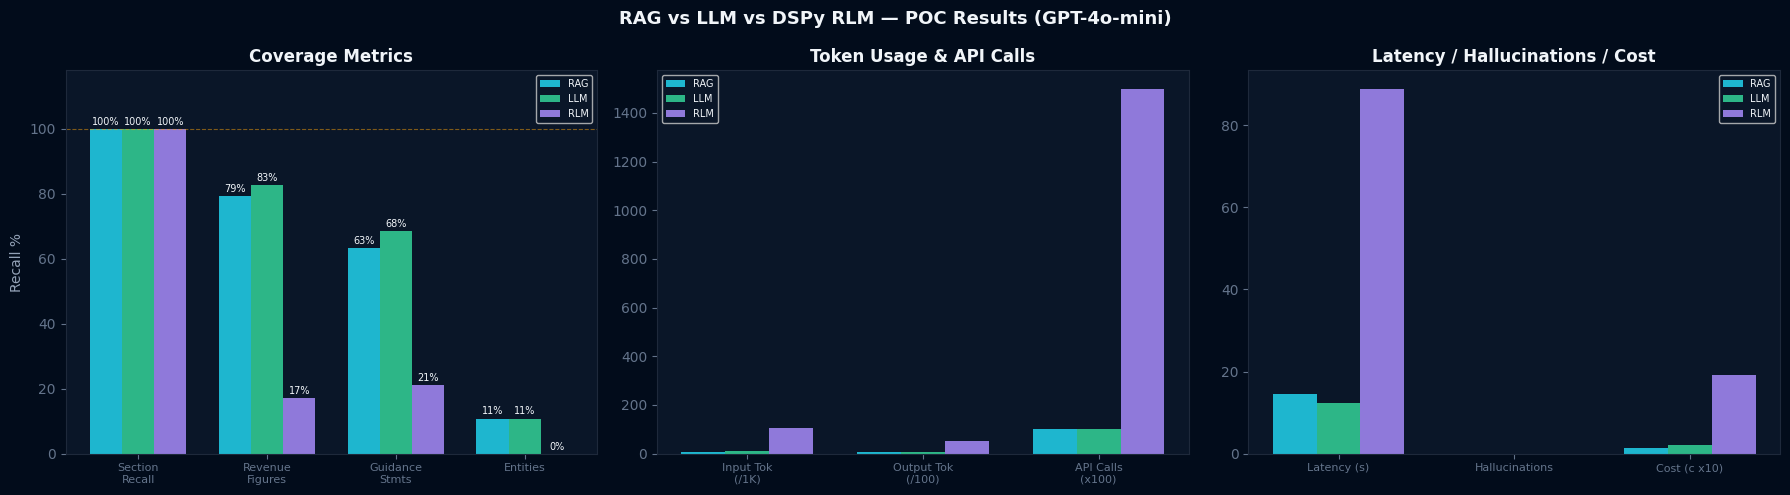

Chart saved -> rag_vs_llm_vs_rlm_results.png


In [16]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    "figure.facecolor": "#020c1b", "axes.facecolor": "#0a1628",
    "axes.edgecolor": "#1e293b",   "axes.labelcolor": "#94a3b8",
    "xtick.color": "#64748b",      "ytick.color": "#64748b",
    "text.color": "#f1f5f9",       "grid.color": "#1e293b",
})

RC, GC, LC = "#22d3ee", "#34d399", "#a78bfa"   # RAG=cyan, LLM=green, RLM=purple
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("RAG vs LLM vs DSPy RLM — POC Results (GPT-4o-mini)",
             color="#f1f5f9", fontsize=13, fontweight="bold")

rs = rag_tracker.summary_dict()
ms = llm_tracker.summary_dict()
ls = rlm_tracker.summary_dict()
w2 = 0.25

# ── Panel 1: Coverage ────────────────────────────────────────
ax = axes[0]
cats = ["Section\nRecall", "Revenue\nFigures", "Guidance\nStmts", "Entities"]
rv = [rs["section_recall_of_5"]/5*100, rs["revenue_recall_pct"],
      rs["guidance_recall_pct"],         rs["entity_recall_pct"]]
mv = [ms["section_recall_of_5"]/5*100, ms["revenue_recall_pct"],
      ms["guidance_recall_pct"],         ms["entity_recall_pct"]]
lv = [ls["section_recall_of_5"]/5*100, ls["revenue_recall_pct"],
      ls["guidance_recall_pct"],         ls["entity_recall_pct"]]
x  = np.arange(len(cats))
b1 = ax.bar(x - w2, rv, w2, label="RAG", color=RC, alpha=0.85)
b2 = ax.bar(x,      mv, w2, label="LLM", color=GC, alpha=0.85)
b3 = ax.bar(x + w2, lv, w2, label="RLM", color=LC, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(cats, fontsize=8)
ax.set_ylim(0, 118); ax.set_ylabel("Recall %")
ax.set_title("Coverage Metrics", color="#f1f5f9", fontweight="bold")
ax.legend(fontsize=7)
ax.axhline(100, color="#f59e0b", ls="--", lw=0.8, alpha=0.5)
for b in list(b1) + list(b2) + list(b3):
    h = b.get_height()
    ax.annotate(f"{h:.0f}%", xy=(b.get_x() + b.get_width()/2, h),
                xytext=(0, 3), textcoords="offset points",
                ha="center", fontsize=7, color="#f1f5f9")

# ── Panel 2: Token Usage ─────────────────────────────────────
ax2 = axes[1]
tcats = ["Input Tok\n(/1K)", "Output Tok\n(/100)", "API Calls\n(x100)"]
rtv = [rs["total_input_tokens"]/1000, rs["total_output_tokens"]/100,
       rs["api_call_count"] * 100]
mtv = [ms["total_input_tokens"]/1000, ms["total_output_tokens"]/100,
       ms["api_call_count"] * 100]
ltv = [ls["total_input_tokens"]/1000, ls["total_output_tokens"]/100,
       ls["api_call_count"] * 100]
x2 = np.arange(len(tcats))
ax2.bar(x2 - w2, rtv, w2, label="RAG", color=RC, alpha=0.85)
ax2.bar(x2,      mtv, w2, label="LLM", color=GC, alpha=0.85)
ax2.bar(x2 + w2, ltv, w2, label="RLM", color=LC, alpha=0.85)
ax2.set_xticks(x2); ax2.set_xticklabels(tcats, fontsize=8)
ax2.set_title("Token Usage & API Calls", color="#f1f5f9", fontweight="bold")
ax2.legend(fontsize=7)

# ── Panel 3: Latency / Hallucinations / Cost ─────────────────
ax3 = axes[2]
lcats = ["Latency (s)", "Hallucinations", "Cost (c x10)"]
rlv = [rs["wall_clock_s"], rs["hallucination_count"],
       rs["estimated_cost_usd"] * 1000]
mlv = [ms["wall_clock_s"], ms["hallucination_count"],
       ms["estimated_cost_usd"] * 1000]
llv = [ls["wall_clock_s"], ls["hallucination_count"],
       ls["estimated_cost_usd"] * 1000]
x3 = np.arange(len(lcats))
ax3.bar(x3 - w2, rlv, w2, label="RAG", color=RC, alpha=0.85)
ax3.bar(x3,      mlv, w2, label="LLM", color=GC, alpha=0.85)
ax3.bar(x3 + w2, llv, w2, label="RLM", color=LC, alpha=0.85)
ax3.set_xticks(x3); ax3.set_xticklabels(lcats, fontsize=8)
ax3.set_title("Latency / Hallucinations / Cost", color="#f1f5f9", fontweight="bold")
ax3.legend(fontsize=7)

plt.tight_layout()
plt.savefig("rag_vs_llm_vs_rlm_results.png", dpi=150, bbox_inches="tight", facecolor="#020c1b")
plt.show()
print("Chart saved -> rag_vs_llm_vs_rlm_results.png")

In [17]:
from IPython.display import HTML, display

SECTIONS = [
    ("executive_summary",  "S1 — Executive Summary"),
    ("revenue_by_segment", "S2 — Revenue by Segment"),
    ("forward_guidance",   "S3 — Forward Guidance"),
    ("risk_factors",       "S4 — Risk Factors"),
    ("analyst_qa_themes",  "S5 — Analyst Q&A Themes"),
]

def fmt(text, populated):
    s = str(text).strip() if text else ""
    if len(s) < 20:
        return '<span style="color:#ef4444;font-style:italic">Not populated</span>'
    icon  = "OK" if populated else "??"
    color = "#16a34a" if populated else "#f59e0b"
    preview = s[:500].replace("\n", "<br>")
    suffix = (f'<br><span style="color:#64748b;font-size:11px">'
              f'[+{len(s)-500} chars]</span>' if len(s) > 500 else "")
    return f'<span style="color:{color};font-weight:bold">{icon}</span> {preview}{suffix}'

html = [
    '<style>'
    '.dt{width:100%;border-collapse:collapse;font-family:Arial,sans-serif;font-size:12px}'
    '.dt th{background:#1e3a5f;color:#fff;padding:6px 10px;text-align:left}'
    '.dt td{padding:6px 10px;vertical-align:top;border:1px solid #e2e8f0}'
    '.sl{background:#0f1f3d;color:#22d3ee;font-weight:bold;white-space:nowrap}'
    '.rc{border-left:3px solid #22d3ee}'
    '.gc{border-left:3px solid #34d399}'
    '.lc{border-left:3px solid #a78bfa}'
    '</style>'
    '<table class="dt"><tr>'
    '<th style="width:12%">Section</th>'
    '<th class="rc" style="width:29%">RAG  (Granite+FAISS+GPT-4o-mini)</th>'
    '<th class="gc" style="width:29%">LLM  (GPT-4o-mini Full Context)</th>'
    '<th class="lc" style="width:30%">RLM  (DSPy+GPT-4o-mini)</th>'
    '</tr>',
]

for key, label in SECTIONS:
    rag_pop = key in rag_tracker.sections_populated
    llm_pop = key in llm_tracker.sections_populated
    rlm_pop = key in rlm_tracker.sections_populated
    row = (f'<tr><td class="sl">{label}</td>'
           f'<td class="rc">{fmt(rag_output.get(key, ""), rag_pop)}</td>'
           f'<td class="gc">{fmt(llm_output.get(key, ""), llm_pop)}</td>'
           f'<td class="lc">{fmt(rlm_output.get(key, ""), rlm_pop)}</td></tr>')
    html.append(row)

html.append("</table>")
display(HTML("".join(html)))

Section,RAG (Granite+FAISS+GPT-4o-mini),LLM (GPT-4o-mini Full Context),RLM (DSPy+GPT-4o-mini)
S1 — Executive Summary,"OK This quarter, revenue was $81.3 billion, up 17% and 15% in constant currency. Gross margin dollars increased 16% and 14% in constant currency while operating income increased 21% and 19% in constant currency. Earnings per share was $4.14, an increase of 24% and 21% in constant currency. Company gross margin percentage was 68%, down slightly year-over-year. Operating expenses increased 5% and 4% in constant currency. Operating margins increased year-over-year to 47%. Microsoft Cloud revenue was $[+223 chars]","OK This quarter, revenue was $81.3 billion, up 17% and 15% in constant currency. Gross margin dollars increased 16% and 14% in constant currency while operating income increased 21% and 19% in constant currency. Earnings per share was $4.14, an increase of 24% and 21% in constant currency. Microsoft Cloud surpassed $50 billion in revenue for the first time, up 26% year-over-year. Capital expenditures were $37.5 billion, and cash flow from operations was $35.8 billion, up 60%. Free cash flow was $5.[+128 chars]","OK Microsoft's earnings call highlighted significant growth in the cloud segment, with expectations for continued revenue growth despite potential risks."
S2 — Revenue by Segment,"OK Intelligent Cloud segment revenue was $32.9 billion, growing 29% and 28% in constant currency. Azure and other cloud services revenue grew 39% and 38% in constant currency. More Personal Computing revenue was $14.3 billion, declining 3%. Productivity and Business Processes revenue was $34.1 billion, growing 16% and 14% in constant currency. M365 commercial cloud revenue increased 17% and 14% in constant currency. M365 consumer cloud revenue increased 29% and 27% in constant currency. LinkedIn re[+114 chars]",OK Revenue from Productivity and Business Processes was $34.1 billion and grew 16% and 14% in constant currency. M365 commercial cloud revenue increased 17% and 14% in constant currency. M365 consumer cloud revenue increased 29% and 27% in constant currency. LinkedIn revenue increased 11% and 10% in constant currency. Dynamics 365 revenue increased 19% and 17% in constant currency. Intelligent Cloud segment revenue was $32.9 billion and grew 29% and 28% in constant currency. Azure and other cloud s[+311 chars],"OK No specific revenue figures were extracted, but guidance indicates strong performance across segments."
S3 — Forward Guidance,"OK For Q3, we expect revenue of $80.65 to $81.75 billion or growth of 15% to 17%. We expect COGS of $26.65 to $26.85 billion, or growth of 22% to 23%. Operating expense of $17.8 to $17.9 billion or growth of 10% to 11%. In Productivity and Business Processes, we expect revenue of $34.25 to $34.55 billion, or growth of 14% to 15%. In Intelligent Cloud, we expect revenue of $34.1 to $34.4 billion, or growth of 27% to 29%. In Azure, we expect Q3 revenue growth to be between 37% and 38% in constant cur[+6 chars]","OK We expect revenue of $80.65 to $81.75 billion or growth of 15% to 17%. We expect COGS of $26.65 to $26.85 billion, or growth of 22% to 23%. Operating expense of $17.8 to $17.9 billion or growth of 10% to 11%. In Productivity and Business Processes, we expect revenue of $34.25 to $34.55 billion, or growth of 14% to 15%. In Intelligent Cloud, we expect revenue of $34.1 to $34.4 billion, or growth of 27% to 29%. In More Personal Computing, we expect revenue to be $12.3 to $12.8 billion.","OK ['We expect FX to increase total revenue growth by 3 points.', 'We expect revenue of $80.65 to $81.75 billion or growth of 15% to 17%.', 'We expect revenue growth to be between 13% and 14% in constant currency.']"
S4 — Risk Factors,OK Rising memory prices could impact capital expenditures and the on-premises server business is expected to decline in the low-single digits. Increased memory pricing could create additional volatility in transactional purchasing. The potential impact on W

## Section 10 — Verdict & Persist
3-way composite scoring, hypothesis verdict, and result persistence.

In [18]:
rs = rag_tracker.summary_dict()
ms = llm_tracker.summary_dict()
ls = rlm_tracker.summary_dict()

def composite(s):
    return (s["section_recall_of_5"]     * 2.0 +
            s["revenue_recall_pct"]/100  * 1.5 +
            s["guidance_recall_pct"]/100 * 1.5 +
            s["entity_recall_pct"]/100   * 0.5 -
            min(s["hallucination_count"], 10) * 0.3)

rag_score = composite(rs)
llm_score = composite(ms)
rlm_score = composite(ls)
scores = {"RAG": rag_score, "LLM": llm_score, "RLM": rlm_score}
best = max(scores, key=scores.get)

print("\n" + "=" * 62)
print("  3-WAY HYPOTHESIS VERDICT")
print("=" * 62)
print(f"\n  Composite accuracy  RAG : {rag_score:.2f}")
print(f"  Composite accuracy  LLM : {llm_score:.2f}")
print(f"  Composite accuracy  RLM : {rlm_score:.2f}")
print(f"\n  Best pipeline: {best}  ({scores[best]:.2f})")
print()

if rlm_score > rag_score:
    lat  = ls['wall_clock_s']       / max(rs['wall_clock_s'], 0.1)
    cost = ls['estimated_cost_usd'] / max(rs['estimated_cost_usd'], 1e-6)
    print(f"  RLM outperforms RAG on accuracy  ({rlm_score:.2f} vs {rag_score:.2f})")
    print(f"  at {lat:.1f}x latency and {cost:.1f}x cost.")
else:
    print(f"  RAG outperforms RLM on accuracy  ({rag_score:.2f} vs {rlm_score:.2f})")

if llm_score >= rag_score and llm_score >= rlm_score:
    print(f"\n  LLM (full context) achieves the best composite score ({llm_score:.2f}).")
    print("  Full context beats retrieval when the document fits in the context window.")

print()
print("  PIPELINE RECOMMENDATIONS:")
print("  +-- RAG  ->  real-time user Q&A  (latency-critical, cost-efficient)")
print("  +-- LLM  ->  single-doc analysis  (when doc fits in context window)")
print("  +-- RLM  ->  multi-doc batch      (completeness-critical, complex reasoning)")
print()
print(f"  Section recall  RAG {rs['section_recall_of_5']}/5  "
      f"LLM {ms['section_recall_of_5']}/5  "
      f"RLM {ls['section_recall_of_5']}/5")
print(f"  Revenue recall  RAG {rs['revenue_recall_pct']}%  "
      f"LLM {ms['revenue_recall_pct']}%  "
      f"RLM {ls['revenue_recall_pct']}%")
print(f"  Hallucinations  RAG {rs['hallucination_count']}  "
      f"LLM {ms['hallucination_count']}  "
      f"RLM {ls['hallucination_count']}")
print(f"  Latency         RAG {rs['wall_clock_s']:.1f}s  "
      f"LLM {ms['wall_clock_s']:.1f}s  "
      f"RLM {ls['wall_clock_s']:.1f}s")
print(f"  Cost            RAG ${rs['estimated_cost_usd']:.5f}  "
      f"LLM ${ms['estimated_cost_usd']:.5f}  "
      f"RLM ${ls['estimated_cost_usd']:.5f}")
print("=" * 62)


  3-WAY HYPOTHESIS VERDICT

  Composite accuracy  RAG : 12.19
  Composite accuracy  LLM : 12.32
  Composite accuracy  RLM : 10.57

  Best pipeline: LLM  (12.32)

  RAG outperforms RLM on accuracy  (12.19 vs 10.57)

  LLM (full context) achieves the best composite score (12.32).
  Full context beats retrieval when the document fits in the context window.

  PIPELINE RECOMMENDATIONS:
  +-- RAG  ->  real-time user Q&A  (latency-critical, cost-efficient)
  +-- LLM  ->  single-doc analysis  (when doc fits in context window)
  +-- RLM  ->  multi-doc batch      (completeness-critical, complex reasoning)

  Section recall  RAG 5/5  LLM 5/5  RLM 5/5
  Revenue recall  RAG 79.3%  LLM 82.8%  RLM 17.2%
  Hallucinations  RAG 0  LLM 0  RLM 0
  Latency         RAG 14.5s  LLM 12.3s  RLM 88.9s
  Cost            RAG $0.00148  LLM $0.00206  RLM $0.01913


In [19]:
results = {
    "rag": rag_tracker.summary_dict(),
    "llm": llm_tracker.summary_dict(),
    "rlm": rlm_tracker.summary_dict(),
    "rag_output": rag_output,
    "llm_output": llm_output,
    "rlm_output": rlm_output,
}
with open("poc_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✓ poc_results.json saved")
print("✓ rag_vs_llm_vs_rlm_results.png saved")

✓ poc_results.json saved
✓ rag_vs_llm_vs_rlm_results.png saved
